In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt

columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]
 
drop_cols = [
    "difficulty",
    "srv_serror_rate", "dst_host_srv_serror_rate",
    "srv_rerror_rate", "dst_host_srv_rerror_rate",
]
categorical_cols = ["protocol_type", "service", "flag"]
 
train_df = pd.read_csv("../data/KDDTrain.txt", names=columns)
test_df  = pd.read_csv("../data/KDDTest.txt",  names=columns)
 
test_labels = test_df["label"].copy()
 
train_df["binary_label"] = train_df["label"].apply(lambda x: 0 if x == "normal" else 1)
test_df["binary_label"]  = test_df["label"].apply(lambda x: 0 if x == "normal" else 1)
 
train_df = train_df.drop(columns=drop_cols + ["label"])
test_df  = test_df.drop(columns=drop_cols  + ["label"])
 
for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])
 
X_train = train_df.drop(columns=["binary_label"])
y_train = train_df["binary_label"]
X_test  = test_df.drop(columns=["binary_label"])
y_test  = test_df["binary_label"]
 
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
 
model = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    scale_pos_weight=spw,
    random_state=42, eval_metric="logloss", n_jobs=-1
)
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [4]:
explainer = shap.TreeExplainer(model)

In [5]:
X_sample = X_test.sample(2000, random_state=42)

shap_values = explainer.shap_values(X_sample)

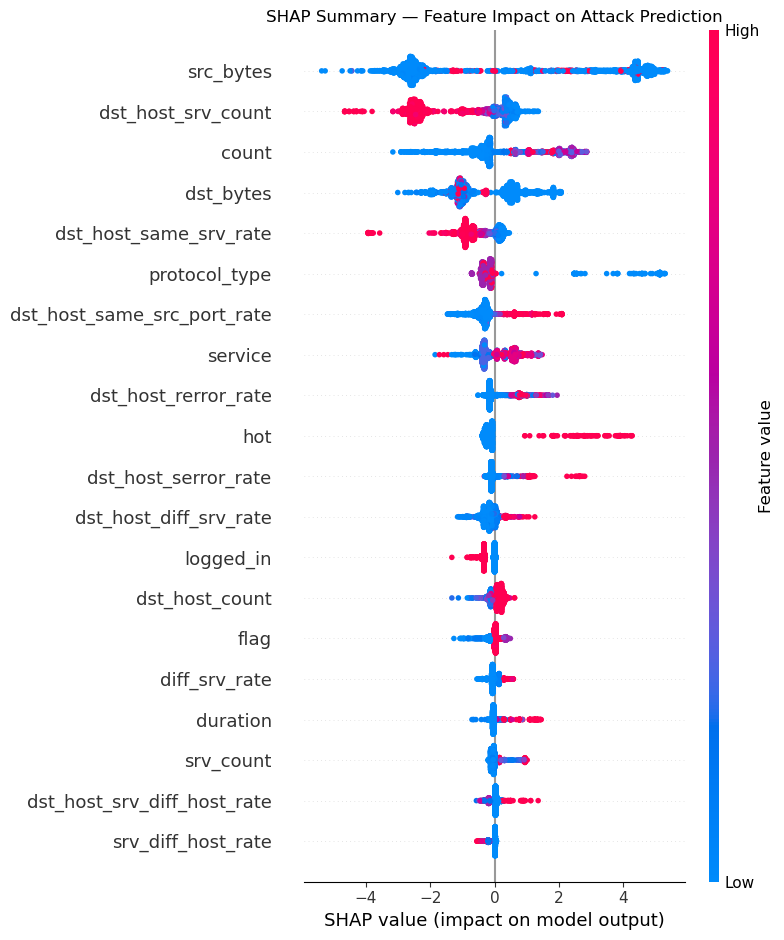

In [7]:
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Summary — Feature Impact on Attack Prediction")
plt.tight_layout()

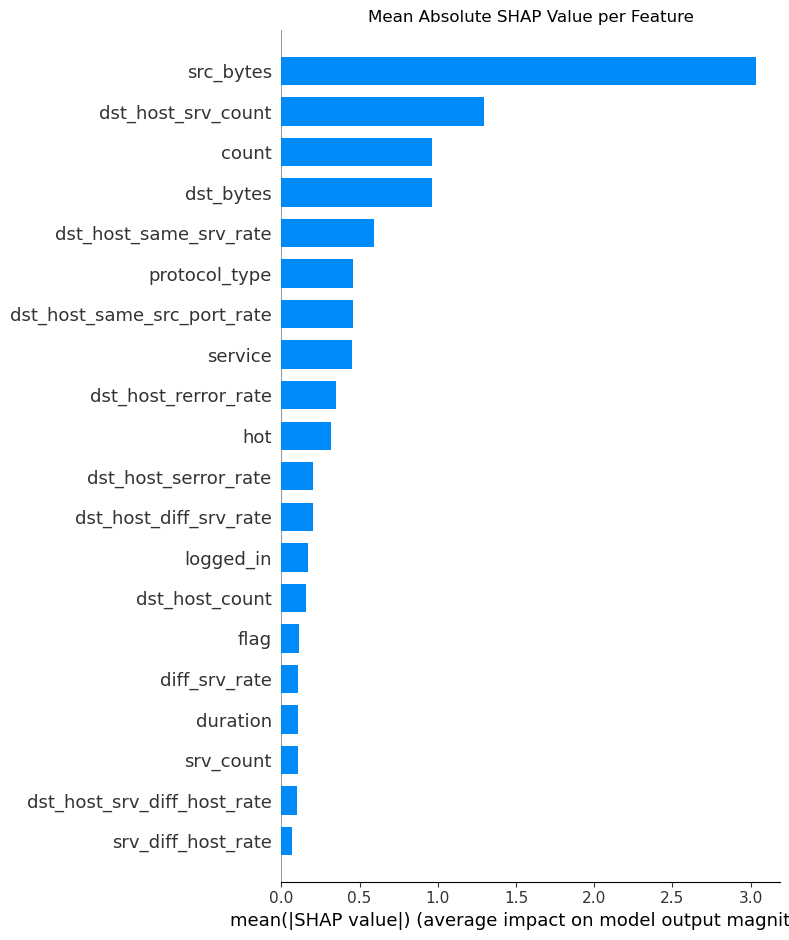

In [9]:
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("Mean Absolute SHAP Value per Feature")
plt.tight_layout()

In [10]:
y_pred = model.predict(X_test)
analysis = pd.DataFrame({
    "true_binary": y_test.values,
    "predicted":   y_pred,
    "true_label":  test_labels.values
}, index=X_test.index)

caught_idx  = analysis[(analysis["true_binary"]==1) & (analysis["predicted"]==1)].index[0]
missed_idx  = analysis[(analysis["true_binary"]==1) & (analysis["predicted"]==0)].index[0]
normal_idx  = analysis[(analysis["true_binary"]==0) & (analysis["predicted"]==0)].index[0]
 
cases = {
    "caught_attack": caught_idx,
    "missed_attack":  missed_idx,
    "correct_normal": normal_idx,
}

base_value = explainer.expected_value
 
for case_name, idx in cases.items():
    row       = X_test.loc[[idx]]          
    sv        = explainer.shap_values(row)
    true_lbl  = analysis.loc[idx, "true_label"]
    pred      = analysis.loc[idx, "predicted"]
 
    print(f"\n--- {case_name} | true: {true_lbl} | predicted: {'attack' if pred==1 else 'normal'} ---")
    print("Top 5 features pushing this prediction:")

    feature_shap = list(zip(X_test.columns, sv[0]))
    feature_shap.sort(key=lambda x: abs(x[1]), reverse=True)
    for feat, val in feature_shap[:5]:
        direction = "→ ATTACK" if val > 0 else "→ NORMAL"
        print(f"  {feat:35s} SHAP={val:+.4f}  {direction}")

    force = shap.force_plot(
        base_value, sv[0], row.iloc[0],
        feature_names=list(X_test.columns),
        show=False
    )
    shap.save_html(f"16_force_{case_name}.html", force)
    print(f"  Saved force plot: 16_force_{case_name}.html")
 
print("\nAll SHAP plots saved.")


--- caught_attack | true: neptune | predicted: attack ---
Top 5 features pushing this prediction:
  src_bytes                           SHAP=+4.3814  → ATTACK
  count                               SHAP=+2.4081  → ATTACK
  dst_host_rerror_rate                SHAP=+0.7585  → ATTACK
  service                             SHAP=+0.6365  → ATTACK
  dst_bytes                           SHAP=+0.5143  → ATTACK
  Saved force plot: 16_force_caught_attack.html

--- missed_attack | true: mscan | predicted: normal ---
Top 5 features pushing this prediction:
  src_bytes                           SHAP=+3.1905  → ATTACK
  count                               SHAP=-1.9959  → NORMAL
  dst_host_rerror_rate                SHAP=+1.4478  → ATTACK
  dst_host_same_src_port_rate         SHAP=-1.0266  → NORMAL
  dst_bytes                           SHAP=-0.6446  → NORMAL
  Saved force plot: 16_force_missed_attack.html

--- correct_normal | true: normal | predicted: normal ---
Top 5 features pushing this prediction: